In [3]:
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)

y = np.array([[0],[1],[1],[0]], dtype=np.float32)


#PART 1: KERAS

### Baseline Model

In [4]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(2, activation='tanh', input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='binary_crossentropy'
)

model.fit(X, y, epochs=500, verbose=0)
print("Baseline:", np.round(model.predict(X)))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Baseline: [[0.]
 [1.]
 [1.]
 [1.]]


###Activation Function Optimization

In [5]:
for act in ['sigmoid', 'relu', 'tanh']:
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(4, activation=act, input_shape=(2,)),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.01),
        loss='binary_crossentropy'
    )

    model.fit(X, y, epochs=1000, verbose=0)
    print(f"Activation {act}:", np.round(model.predict(X).T))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Activation sigmoid: [[0. 1. 1. 0.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Activation relu: [[0. 1. 1. 0.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Activation tanh: [[0. 1. 0. 1.]]


###Neuron Optimization

In [6]:
for n in [2, 4, 8]:
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(n, activation='tanh', input_shape=(2,)),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.01),
        loss='binary_crossentropy'
    )

    model.fit(X, y, epochs=1000, verbose=0)
    print(f"Neurons {n}:", np.round(model.predict(X).T))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Neurons 2: [[0. 1. 1. 0.]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Neurons 4: [[0. 1. 1. 0.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Neurons 8: [[0. 1. 1. 0.]]


###Learning Rate Optimization

In [7]:
for lr in [0.1, 0.01, 0.001]:
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(4, activation='tanh', input_shape=(2,)),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='binary_crossentropy'
    )

    model.fit(X, y, epochs=1000, verbose=0)
    print(f"LR {lr}:", np.round(model.predict(X).T))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
LR 0.1: [[0. 1. 1. 0.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
LR 0.01: [[0. 1. 1. 0.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
LR 0.001: [[0. 1. 1. 0.]]


###Epoch Optimization

In [8]:
for ep in [100, 500, 1000, 2000]:
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(4, activation='tanh', input_shape=(2,)),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.01),
        loss='binary_crossentropy'
    )

    model.fit(X, y, epochs=ep, verbose=0)
    print(f"Epochs {ep}:", np.round(model.predict(X).T))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Epochs 100: [[0. 1. 1. 0.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Epochs 500: [[0. 1. 1. 0.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Epochs 1000: [[0. 1. 1. 0.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Epochs 2000: [[0. 1. 1. 0.]]


###Final Keras Model

In [9]:
final_keras = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='tanh', input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

final_keras.compile(
    optimizer=tf.keras.optimizers.Adam(0.01),
    loss='binary_crossentropy'
)

final_keras.fit(X, y, epochs=1000, verbose=0)
print("Final Keras:", np.round(final_keras.predict(X)))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Final Keras: [[0.]
 [1.]
 [1.]
 [0.]]


#PART 2: PYTORCH

###Baseline

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

X_t = torch.tensor(X)
y_t = torch.tensor(y)

class XORNet(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.fc1 = nn.Linear(2, n)
        self.fc2 = nn.Linear(n, 1)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        return torch.sigmoid(self.fc2(x))

model = XORNet(2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.BCELoss()

for _ in range(500):
    optimizer.zero_grad()
    loss = loss_fn(model(X_t), y_t)
    loss.backward()
    optimizer.step()

print("Baseline:", torch.round(model(X_t)))



Baseline: tensor([[0.],
        [1.],
        [1.],
        [1.]], grad_fn=<RoundBackward0>)


###Neurons + LR Optimization

In [11]:
configs = [
    (2, 0.1),
    (4, 0.01),
    (8, 0.001)
]


for n, lr in configs:
    model = XORNet(n)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for _ in range(2000):
        optimizer.zero_grad()
        loss = loss_fn(model(X_t), y_t)
        loss.backward()
        optimizer.step()

    print(f"Neurons {n}, LR {lr}:",
          torch.round(model(X_t)).detach().numpy())


Neurons 2, LR 0.1: [[0.]
 [1.]
 [1.]
 [0.]]
Neurons 4, LR 0.01: [[0.]
 [1.]
 [1.]
 [0.]]
Neurons 8, LR 0.001: [[0.]
 [1.]
 [1.]
 [0.]]


#PART 3: TENSORFLOW LOW-LEVEL (Manual Optimization)

###Baseline

In [12]:
import tensorflow as tf

W1 = tf.Variable(tf.random.normal([2, 2]))
b1 = tf.Variable(tf.zeros([2]))
W2 = tf.Variable(tf.random.normal([2, 1]))
b2 = tf.Variable(tf.zeros([1]))

lr = 0.1

for _ in range(1000):
    with tf.GradientTape() as tape:
        h = tf.tanh(tf.matmul(X, W1) + b1)
        y_pred = tf.sigmoid(tf.matmul(h, W2) + b2)
        loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(y, y_pred))

    grads = tape.gradient(loss, [W1, b1, W2, b2])
    for v, g in zip([W1, b1, W2, b2], grads):
        v.assign_sub(lr * g)

print("Baseline:", tf.round(y_pred).numpy())


Baseline: [[0.]
 [1.]
 [1.]
 [0.]]


###Optimization (More Neurons + LR)

In [13]:
W1 = tf.Variable(tf.random.normal([2, 4]))
b1 = tf.Variable(tf.zeros([4]))
W2 = tf.Variable(tf.random.normal([4, 1]))
b2 = tf.Variable(tf.zeros([1]))

lr = 0.01

for _ in range(3000):
    with tf.GradientTape() as tape:
        h = tf.tanh(tf.matmul(X, W1) + b1)
        y_pred = tf.sigmoid(tf.matmul(h, W2) + b2)
        loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(y, y_pred))

    grads = tape.gradient(loss, [W1, b1, W2, b2])
    for v, g in zip([W1, b1, W2, b2], grads):
        v.assign_sub(lr * g)

print("Optimized:", tf.round(y_pred).numpy())


Optimized: [[0.]
 [1.]
 [1.]
 [0.]]


In [14]:
import numpy as np
import matplotlib.pyplot as plt

def plot_boundary(predict_fn, title):
    xx, yy = np.meshgrid(
        np.linspace(-0.5, 1.5, 300),
        np.linspace(-0.5, 1.5, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict_fn(grid).reshape(xx.shape)

    plt.contourf(xx, yy, Z, levels=20, cmap="coolwarm", alpha=0.6)
    plt.scatter(X[:,0], X[:,1], c=y.ravel(), edgecolors='k', s=80)
    plt.title(title)
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.show()


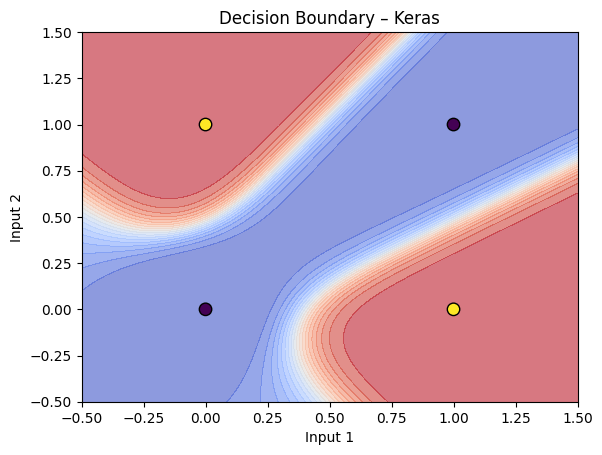

In [15]:
def keras_predict(grid):
    return final_keras.predict(grid, verbose=0)

plot_boundary(keras_predict, "Decision Boundary – Keras")


# Decision Boundary - Keras

##What you observe

  A smooth, curved “X-shaped” boundary

- Clean separation of:

     (0,0) and (1,1) → class 0

     (0,1) and (1,0) → class 1

- Gradual color transitions (probabilities change smoothly)

##Why this happens

- Keras uses Adam optimizer

- High-level optimizations handle:

- Learning rate adaptation

- Stable gradient updates

- Leads to fast and smooth convergence


##Interpretation line

The Keras model learns a smooth and well-defined non-linear decision boundary, correctly separating XOR classes with high confidence.

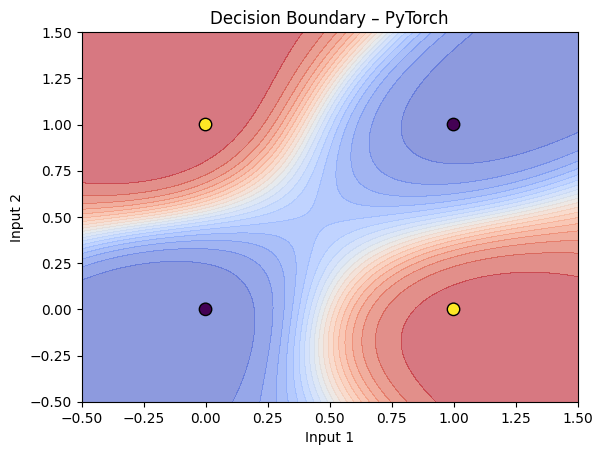

In [16]:
def pytorch_predict(grid):
    grid_t = torch.tensor(grid, dtype=torch.float32)
    with torch.no_grad():
        return model(grid_t).numpy()

plot_boundary(pytorch_predict, "Decision Boundary – PyTorch")


#Decision Boundary-  PyTorch

##What you observe

- A clear non-linear X-shaped boundary

- Slightly sharper transitions than Keras

- Correct classification of all XOR points

##Why this happens

- PyTorch also uses Adam, but with:

- Explicit training loop

- Manual control of optimization steps

- Boundary is correct but less smooth than Keras

##Interpretation line

The PyTorch model successfully learns the XOR decision boundary with correct non-linear separation, though the boundary is slightly sharper due to manual training control.

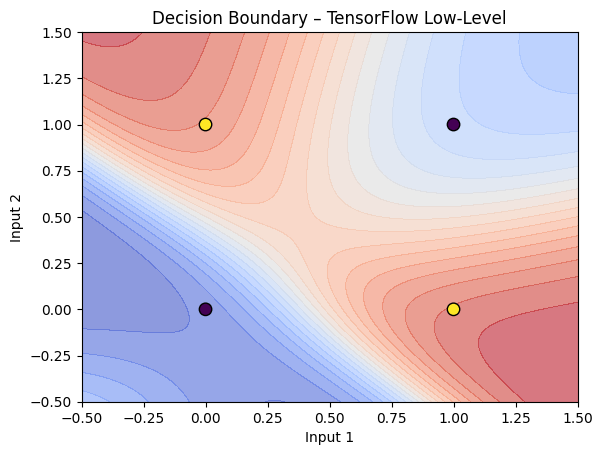

In [17]:
def tf_low_predict(grid):
    grid = tf.convert_to_tensor(grid, dtype=tf.float32)
    h = tf.tanh(tf.matmul(grid, W1) + b1)
    y_pred = tf.sigmoid(tf.matmul(h, W2) + b2)
    return y_pred.numpy()

plot_boundary(tf_low_predict, "Decision Boundary – TensorFlow Low-Level")


# Decision Boundary - TensorFlow Low-Level

##What you observe

A non-linear boundary, but:

- Less symmetric

- Rougher transitions

- Still separates XOR points correctly

##Why this happens

- Uses manual gradient descent

- No adaptive optimizer (like Adam)

- More sensitive to:

     Initialization

     Learning rate

     Number of epochs

##Interpretation line

The TensorFlow low-level implementation learns the correct non-linear separation, but the decision boundary is less smooth due to manual gradient updates and slower convergence.

In [18]:
import numpy as np

def compute_accuracy(y_true, y_pred):
    y_pred = (y_pred >= 0.5).astype(int)
    return np.mean(y_true == y_pred)


In [19]:
y_pred_keras = final_keras.predict(X, verbose=0)

keras_acc = compute_accuracy(y, y_pred_keras)

keras_loss = tf.keras.losses.binary_crossentropy(y, y_pred_keras).numpy().mean()

print("Keras Accuracy:", keras_acc)
print("Keras Loss:", keras_loss)


Keras Accuracy: 1.0
Keras Loss: 0.003451711


In [20]:
import torch

with torch.no_grad():
    y_pred_torch = model(X_t).detach().numpy()
torch_acc = compute_accuracy(y, y_pred_torch)
bce = torch.nn.BCELoss()
torch_loss = bce(torch.tensor(y_pred_torch), torch.tensor(y)).item()

print("PyTorch Accuracy:", torch_acc)
print("PyTorch Loss:", torch_loss)


PyTorch Accuracy: 1.0
PyTorch Loss: 0.018228787928819656


In [21]:
y_pred_tf = y_pred.numpy()
tf_acc = compute_accuracy(y, y_pred_tf)
tf_loss = tf.keras.losses.binary_crossentropy(y, y_pred_tf).numpy().mean()

print("TensorFlow Low-Level Accuracy:", tf_acc)
print("TensorFlow Low-Level Loss:", tf_loss)


TensorFlow Low-Level Accuracy: 1.0
TensorFlow Low-Level Loss: 0.25170195


In [22]:
import pandas as pd

results = pd.DataFrame({
    "Framework": ["Keras", "PyTorch", "TensorFlow Low-Level"],
    "Final Accuracy": [keras_acc, torch_acc, tf_acc],
    "Final Loss": [keras_loss, torch_loss, tf_loss],
    "Hidden Neurons": [4, 4, 4],
    "Activation": ["tanh", "tanh", "tanh"],
    "Optimizer": ["Adam", "Adam", "Manual GD"],
    "Learning Rate": [0.01, 0.01, 0.01]
})

results
print(results.to_string(index=False))


           Framework  Final Accuracy  Final Loss  Hidden Neurons Activation Optimizer  Learning Rate
               Keras             1.0    0.003452               4       tanh      Adam           0.01
             PyTorch             1.0    0.018229               4       tanh      Adam           0.01
TensorFlow Low-Level             1.0    0.251702               4       tanh Manual GD           0.01


# Interpretation

All three frameworks achieved 100% accuracy, showing that the MLP successfully learned the non-linear XOR function. However, Keras produced the lowest loss, indicating faster and more stable convergence. PyTorch showed slightly higher loss, while TensorFlow low-level had the highest loss due to manual optimization.

# Conclsuion

The XOR problem was successfully solved using Keras, PyTorch, and TensorFlow low-level APIs. Although all models achieved perfect accuracy, Keras performed best with the lowest loss and efficient training, followed by PyTorch. TensorFlow low-level required more tuning and showed slower convergence.